# Time-Series Analysis

## Objective

Understand the time-series behaviour of store-level weekly sales before choosing a forecasting approach: is there a trend, is there seasonality (and of what kind), how volatile is the series, and do stores behave differently from each other. This determines which baseline and which forecasting models are actually justified.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

merged = pd.read_csv("../data/processed/merged_store_dept_week.csv", parse_dates=["Date"])

store_week = merged.groupby(["Store", "Date"]).agg(
    Weekly_Sales=("Weekly_Sales", "sum"),
    IsHoliday=("IsHoliday", "first"),
    Type=("Type", "first"),
    Size=("Size", "first")
).reset_index()

print(store_week.shape)
store_week.head()

(6435, 6)


,Store,Date,Weekly_Sales,IsHoliday,Type,Size
0,1,2010-02-05,1643690.90,False,A,151315
1,1,2010-02-12,1641957.44,True,A,151315
2,1,2010-02-19,1611968.17,False,A,151315
3,1,2010-02-26,1409727.59,False,A,151315
4,1,2010-03-05,1554806.68,False,A,151315


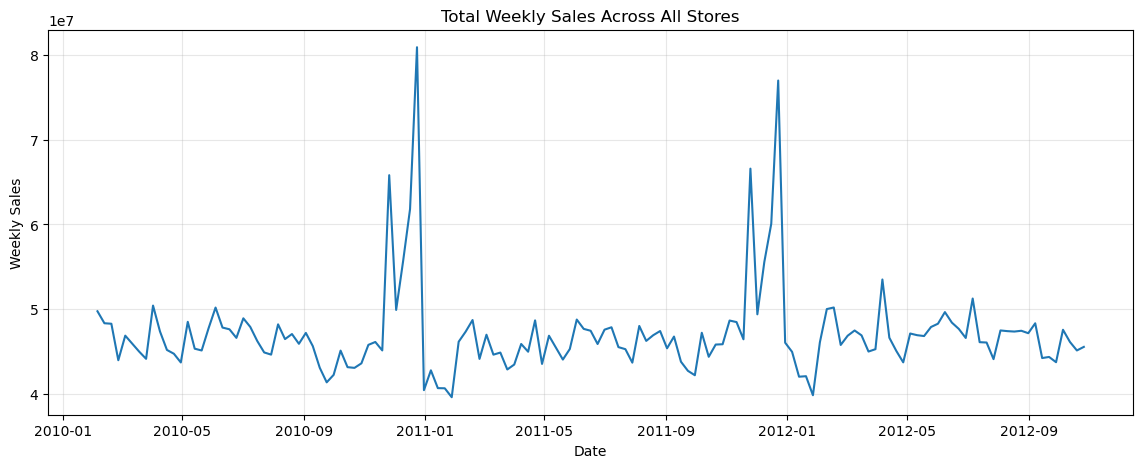

In [5]:
total_weekly = store_week.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(14,5))
plt.plot(total_weekly.index, total_weekly.values)
plt.title("Total Weekly Sales Across All Stores")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.grid(alpha=0.3)
plt.show()

### Holiday Effect

In [8]:
holiday_avg = store_week.groupby("IsHoliday")["Weekly_Sales"].mean()
print(holiday_avg)
print()
print("Holiday weeks are", round(holiday_avg[True] / holiday_avg[False], 2), "x non-holiday average")

IsHoliday
False    1.041256e+06
True     1.122888e+06
Name: Weekly_Sales, dtype: float64

Holiday weeks are 1.08 x non-holiday average


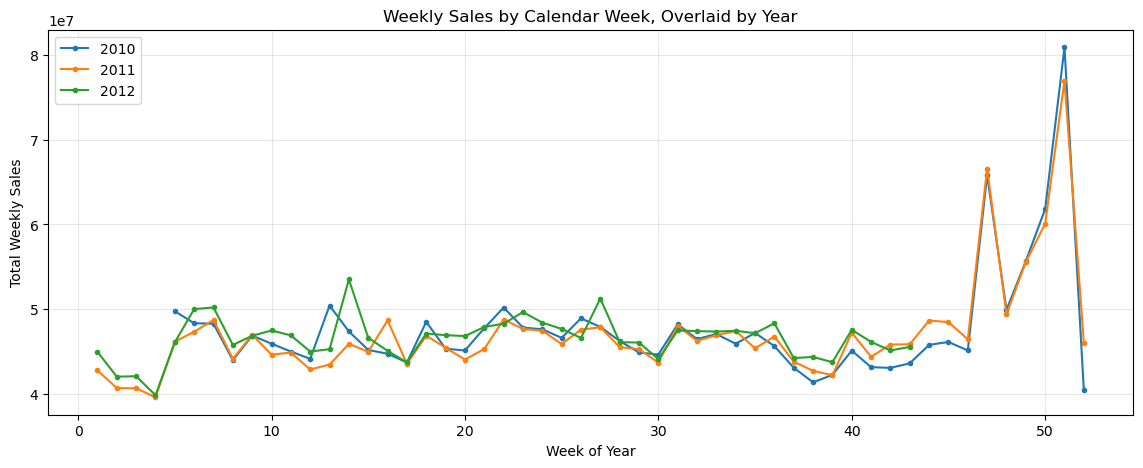

In [10]:
store_week["Year"] = store_week["Date"].dt.year
store_week["Week"] = store_week["Date"].dt.isocalendar().week

yearly = store_week.groupby(["Year","Week"])["Weekly_Sales"].sum().reset_index()

plt.figure(figsize=(14,5))
for yr in sorted(yearly["Year"].unique()):
    subset = yearly[yearly["Year"] == yr]
    plt.plot(subset["Week"], subset["Weekly_Sales"], label=str(yr), marker="o", markersize=3)
plt.title("Weekly Sales by Calendar Week, Overlaid by Year")
plt.xlabel("Week of Year")
plt.ylabel("Total Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Findings: Trend & Seasonality

**Observed:** store_week has 6,435 rows (45 stores × 143 weeks), confirming complete store-level coverage. The overall weekly sales series shows no strong long-term upward or downward trend across 2010-2012 — it oscillates in a fairly stable band, punctuated by two sharp annual spikes near the end of each year (Nov/Dec). These spikes recur at the same calendar week range in both 2010 and 2011 (2012 has no visible year-end spike only because train data ends 2012-10-26, before that period). The blanket holiday-vs-non-holiday average is a modest 1.08x (1,122,888 vs 1,041,256), which understates what's happening: IsHoliday covers four different holidays (Super Bowl, Labor Day, Thanksgiving, Christmas) of very different sizes, and the two huge visible spikes are diluted in a single average alongside the mild ones.

**Decision:** Treat this as a series with weak/no trend but strong, calendar-recurring seasonality concentrated in specific holiday weeks rather than "holidays" as a uniform category. A seasonal-naive baseline (same week last year) is justified. Any regression/ML model should get holiday identity as a feature (which specific holiday, not just a boolean flag), not just IsHoliday, since the four holidays clearly don't have equal impact.

**Why:** Fabricating a single "holidays increase sales by X%" claim would misrepresent the data — the effect is real but concentrated, not uniform. This matters directly for model and feature choice: a boolean IsHoliday feature would force the model to treat Labor Day and Christmas as equivalent, which the data clearly contradicts.

## Store-Level Comparison

In [14]:
store_stats = store_week.groupby("Store").agg(
    avg_weekly_sales=("Weekly_Sales", "mean"),
    std_weekly_sales=("Weekly_Sales", "std"),
    Type=("Type", "first"),
    Size=("Size", "first")
).reset_index()

store_stats["coeff_of_variation"] = store_stats["std_weekly_sales"] / store_stats["avg_weekly_sales"]

store_stats.sort_values("avg_weekly_sales", ascending=False).head(10)

,Store,avg_weekly_sales,std_weekly_sales,Type,Size,coeff_of_variation
19,20,2.107677e+06,275900.562742,A,203742,0.130903
3,4,2.094713e+06,266201.442297,A,205863,0.127083
13,14,2.020978e+06,317569.949476,A,200898,0.157137
12,13,2.003620e+06,265506.995776,A,219622,0.132514
1,2,1.925751e+06,237683.694682,A,202307,0.123424
9,10,1.899425e+06,302262.062504,B,126512,0.159133
26,27,1.775216e+06,239930.135688,A,204184,0.135155
5,6,1.564728e+06,212525.855862,A,202505,0.135823
0,1,1.555264e+06,155980.767761,A,151315,0.100292
38,39,1.450668e+06,217466.454833,A,184109,0.149908


In [16]:
store_stats.sort_values("coeff_of_variation", ascending=False).head(10)

,Store,avg_weekly_sales,std_weekly_sales,Type,Size,coeff_of_variation
34,35,9.197250e+05,211243.457791,B,103681,0.229681
6,7,5.706173e+05,112585.469220,B,70713,0.197305
14,15,6.233125e+05,120538.652043,B,123737,0.193384
28,29,5.394514e+05,99120.136596,B,93638,0.183742
22,23,1.389864e+06,249788.038068,B,114533,0.179721
20,21,7.560691e+05,128752.812853,B,140167,0.170292
44,45,7.859814e+05,130168.526635,B,118221,0.165613
15,16,5.192477e+05,85769.680133,B,57197,0.165181
17,18,1.084718e+06,176641.510839,B,120653,0.162845
35,36,3.735120e+05,60725.173579,A,39910,0.162579


In [18]:
type_summary = store_stats.groupby("Type").agg(
    n_stores=("Store", "count"),
    avg_sales=("avg_weekly_sales", "mean"),
    avg_size=("Size", "mean"),
    avg_cv=("coeff_of_variation", "mean")
)
print(type_summary)

      n_stores     avg_sales       avg_size    avg_cv
Type                                                 
A           22  1.376673e+06  177247.727273  0.126316
B           17  8.229950e+05  101190.705882  0.161622
C            6  4.726148e+05   40541.666667  0.073533


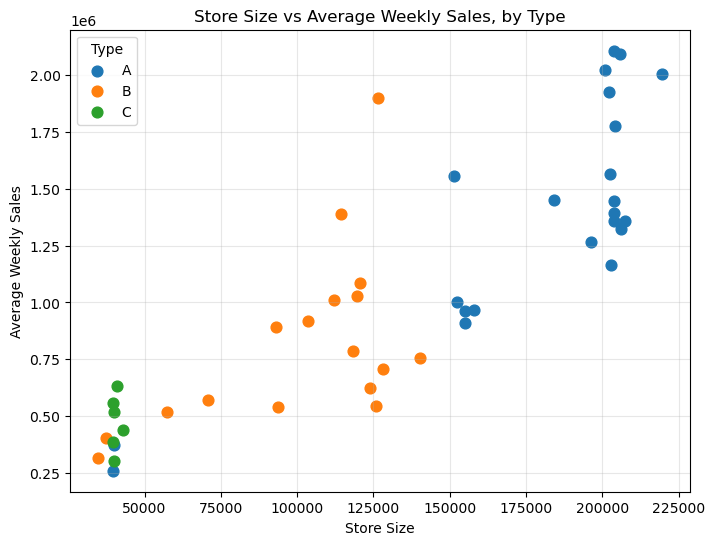

In [20]:
plt.figure(figsize=(8,6))
for t in store_stats["Type"].unique():
    subset = store_stats[store_stats["Type"] == t]
    plt.scatter(subset["Size"], subset["avg_weekly_sales"], label=t, s=60)
plt.xlabel("Store Size")
plt.ylabel("Average Weekly Sales")
plt.title("Store Size vs Average Weekly Sales, by Type")
plt.legend(title="Type")
plt.grid(alpha=0.3)
plt.show()

### Findings: Store-Level Comparison

**Observed:** Store Type strongly separates stores by scale — Type A (22 stores, avg size ~177K sq ft, avg weekly sales ~$1.38M) are consistently larger and higher-selling than Type B (17 stores, avg size ~101K, avg sales ~$823K) and Type C (6 stores, avg size ~41K, avg sales ~$473K). The size-vs-sales scatter shows near-complete visual separation by Type.

The top 10 stores by average weekly sales are almost entirely Type A (Stores 20, 4, 14, 13, 2, 27, 6, 1, 39), with one notable exception: Store 10 (Type B) ranks 6th overall despite its smaller size class, outperforming several Type A stores.

Volatility tells a different story than raw sales: the 5 most volatile stores by coefficient of variation (std/mean, which normalizes for store size) are Stores 35, 7, 15, 29, 23 — every one of them is Type B. Type B stores average a CV of 0.162 versus 0.126 for Type A and 0.074 for Type C.

**Decision:** Store Type is a meaningful, near-deterministic grouping (not just a label) and should be included as a categorical feature. Type B stores, and Store 10 specifically as a high-performing outlier, will be flagged for closer attention in the store-level forecast error analysis later — we should expect Type B stores to have higher forecast error even after accounting for their smaller scale.

**Why:** This directly informs later modelling: a global model should include Type/Size as features rather than assuming stores are exchangeable, and the eventual store-level error breakdown should be checked against this volatility ranking to see if hard-to-forecast stores line up with what we already observed here.